In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
import sys
from pathlib import Path
# Add project root to path
project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))
from src.PCAalg import PCA_MP

This notebook is used to generate the illustrative figure in the main text, to compare StablePCA against PooledPCA.

In [ ]:
def generate_sources(coefficients, n_samples):
    """Generate 2D Gaussian sources given coefficients and sample sizes.

    Args:
        coefficients: list of slopes for X2 = coef * X1 + noise
        n_samples: list of sample sizes for each source
    """
    sources = []
    for i, coef in enumerate(coefficients):
        if isinstance(n_samples, int):
            n = n_samples
        else:
            n = n_samples[i]
        X1 = np.random.normal(0, np.sqrt(3), n)
        X2 = coef * X1 + np.random.normal(0, 0.2, n)
        sources.append(np.column_stack((X1, X2)))
    return sources

def fit_all_pca(sources, max_iter=2000, tol=1e-8):
    """Fit Pooled PCA, StablePCA, SquaredPCA, RegretPCA on a list of source datasets.
    """
    X_all = np.vstack(sources)
    pca_pooled = PCA(n_components=1).fit(X_all)
    # StablePCA
    pca_stable = PCA_MP(n_components=1)
    pca_stable.fit(sources, max_iter=max_iter, tol=tol, check_dual=True, verbose=False)
    
    return pca_pooled, pca_stable


In [3]:
def plot_setting(ax, sources, pca_pooled, pca_stable,
                 title, source_colors, scales=[3.0, 3.0, 3.0, 3.0]):
    """
    Scatter the sources and overlay PC1 lines for pooled, stable, fair PCA.
    
    scales: (scale_pooled, scale_stable, scale_fair) for line lengths.
    """
    # Scatter for each source
    for i, src in enumerate(sources):
        ax.scatter(
            src[:, 0], src[:, 1],
            alpha=0.35,
            color=source_colors[i],
            s=18,
            edgecolors='none',
            label=f"Source {i+1}"
        )
    
    def draw_pc(ax, model, color, scale, label, linestyle='-'):
        # model.components_[0] is length-2 direction if n_components=1
        direction = model.components_[0]
        length = scale * np.sqrt(model.explained_variance_[0])
        mean = model.mean_
        line = direction * length
        ax.plot(
            [mean[0] - line[0], mean[0] + line[0]],
            [mean[1] - line[1], mean[1] + line[1]],
            color=color,
            linewidth=3.0,
            linestyle=linestyle,
            label=label
        )
    
    # Draw PC1 lines
    draw_pc(ax, pca_pooled,  color='#222222', scale=scales[0],
            label='Pooled PC1', linestyle='--')
    draw_pc(ax, pca_stable,  color="#D54E00", scale=scales[1],
            label='Stable PC1')

    # Cosmetics (NeurIPS-ish)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')
    ax.set_title(title, pad=10)
    
    # ax.grid(True, alpha=0.3)
    ax.grid(True, which='both', linestyle=':', linewidth=0.6, alpha=0.4)
    ax.set_facecolor('white')
    
    # Only left and bottom spines
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    # Slightly thinner axes
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)

### Plotting Style

In [ ]:
# Set random seed for reproducibility
np.random.seed(20)

# ------------------------------------------------------------
# NeurIPS-ish global style
# ------------------------------------------------------------
plt.rcParams.update({
    # --- NeurIPS-style, larger text for print ---
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",

    "figure.dpi": 600,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "black",

    # Scaled up for visibility in print
    "axes.titlesize": 18,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 15,

    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": False,
    "lines.linewidth": 2.0,
})

# Colors for the three sources (muted, NeurIPS-ish)
# Roughly similar to many paper palettes: blue, green, orange
source_colors = [
    "#4C72B0",  # muted blue
    "#55A868",  # muted green
    "#8172B2",  # soft purple
]

### Plotting 3 Settings

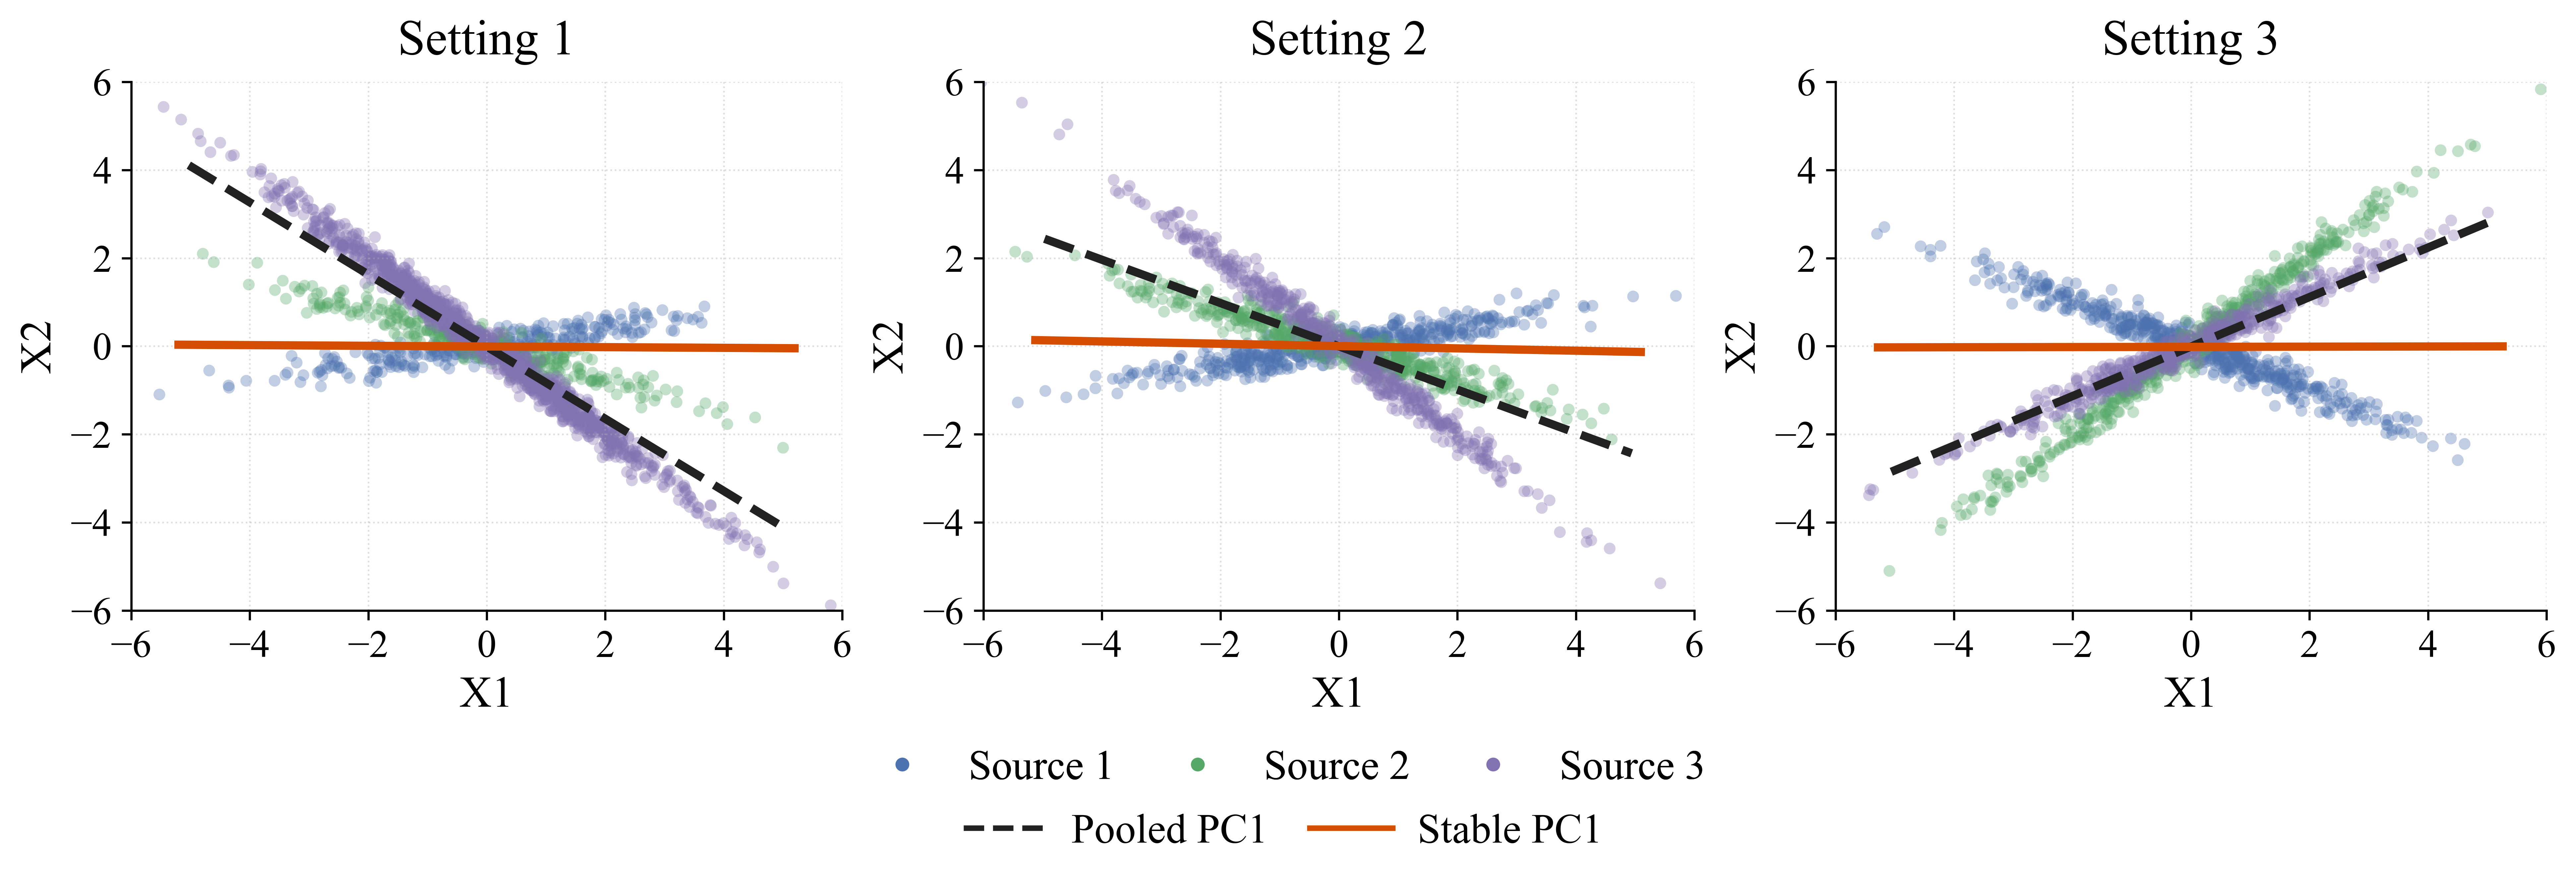

In [ ]:
# Create figure with three subplots
fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(13, 4))
plt.subplots_adjust(bottom=0.23, wspace=0.25)

# ------------------------------------------------------------
# Setting 1: Uneven sample sizes + coeffs [0.2, -0.4, -1]
# ------------------------------------------------------------
coefficients_set0 = [0.2, -0.4, -1]
nl_samples_set0 = [300, 300, 1200]  # uneven sample sizes
sources_set0 = generate_sources(coefficients_set0, nl_samples_set0)
pca_combined_set0, pca_stable_set0 = fit_all_pca(sources_set0)
plot_setting(
    ax=ax0,
    sources=sources_set0,
    pca_pooled=pca_combined_set0,
    pca_stable=pca_stable_set0,
    title='Setting 1',
    source_colors=source_colors,
    scales=(3.0, 3.0, 3.0, 3.0)
)

# ------------------------------------------------------------
# Setting 2: Even sample sizes + coeffs [0.2, -0.4, -1]
# ------------------------------------------------------------
coefficients_set1 = [0.2, -0.4, -1]
n_samples = 500
sources_set1 = generate_sources(coefficients_set1, n_samples)
pca_combined_set1, pca_stable_set1 = fit_all_pca(sources_set1)

plot_setting(
    ax=ax1,
    sources=sources_set1,
    pca_pooled=pca_combined_set1,
    pca_stable=pca_stable_set1,
    title='Setting 2',
    source_colors=source_colors,
    scales=(3.0, 3.0, 3.0, 3.0)
)

# ------------------------------------------------------------
# Setting 3: Even sample sizes + new coeffs [-0.5, 1, 0.6]
# ------------------------------------------------------------
coefficients_set2 = [-0.5, 1.0, 0.6]
sources_set2 = generate_sources(coefficients_set2, n_samples)
pca_combined_set2, pca_stable_set2 = fit_all_pca(sources_set2)

plot_setting(
    ax=ax2,
    sources=sources_set2,
    pca_pooled=pca_combined_set2,
    pca_stable=pca_stable_set2,
    title='Setting 3',
    source_colors=source_colors,
    scales=(3.0, 3.0, 3.0, 3.0)
)

# --- First row: Sources ---
legend_sources = [
    Line2D([0], [0], marker='o', color='w', label='Source 1',
           markerfacecolor=source_colors[0], markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Source 2',
           markerfacecolor=source_colors[1], markersize=6),
    Line2D([0], [0], marker='o', color='w', label='Source 3',
           markerfacecolor=source_colors[2], markersize=6),
]

# --- Second row: Approaches ---
legend_methods = [
    Line2D([0], [0], color='#222222', linestyle='--', lw=2.0, label='Pooled PC1'),
    Line2D([0], [0], color="#D54E00", lw=2.0, label='Stable PC1'),
]

# Add two separate legends
leg1 = fig.legend(
    handles=legend_sources,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.6
)

leg2 = fig.legend(
    handles=legend_methods,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.13),
    ncol=3,
    frameon=False,
    columnspacing=1.0,
    handletextpad=0.6
)

# Make sure both show
fig.add_artist(leg1)

plt.tight_layout(rect=[0, 0.05, 1, 1])
# plt.savefig('../Figures/illus_stablepca.png', bbox_inches='tight', dpi=600)
plt.show()